In [1]:
# Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

os.makedirs("notebooks/plots", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [3]:
#Loading Data

In [4]:
df = pd.read_parquet("../data/crimes_sample.parquet")

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")

Shape: (500000, 26)

Column names:
['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Latitude', 'Longitude', 'Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 'Season', 'Crime_Severity_Score']

Data types:
ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                           int64
Domestic                         int64
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                        object
X Coordinate                   float64
Y

In [5]:
# Missing value audit

Columns with missing values:
                      Missing Count  Missing %
Location Description           1698       0.34
Community Area                   35       0.01
Ward                             11       0.00


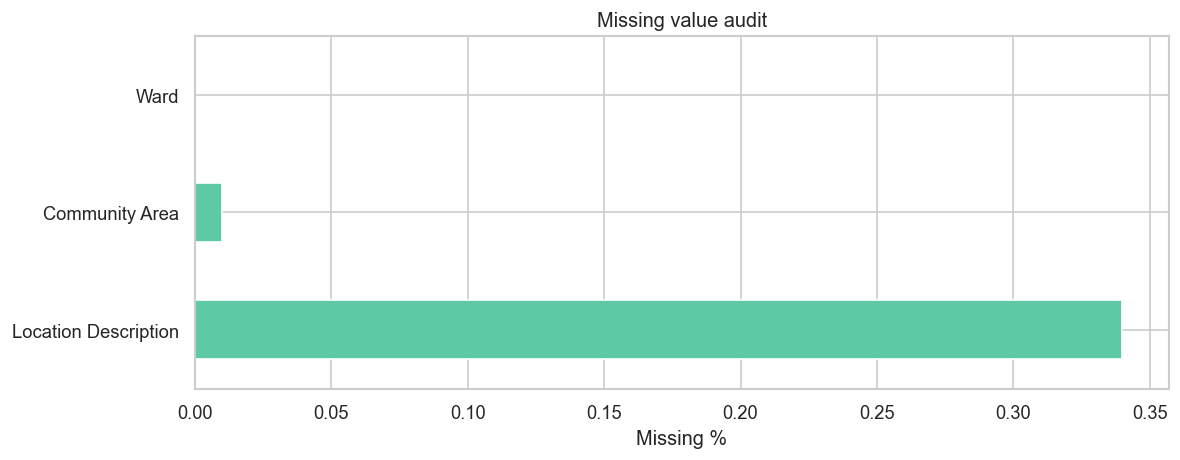

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print("Columns with missing values:")
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
missing_df["Missing %"].plot(kind="barh", ax=ax, color="#5DCAA5")
ax.set_xlabel("Missing %")
ax.set_title("Missing value audit")
plt.tight_layout()
plt.savefig("notebooks/plots/01_missing_values.png")
plt.show()

In [7]:
# Handling remaining null values

In [8]:
fill_map = {
    "Ward": df["Ward"].median(),
    "Community Area": df["Community Area"].median(),
    "District": df["District"].median(),
    "X Coordinate": df["X Coordinate"].median(),
    "Y Coordinate": df["Y Coordinate"].median(),
    "Location Description": "UNKNOWN",
    "FBI Code": "UNKNOWN",
    "IUCR": "UNKNOWN",
    "Beat": df["Beat"].median(),
}

for col, val in fill_map.items():
    if col in df.columns:
        df[col].fillna(val, inplace=True)

df["District"] = df["District"].astype(int)
df["Ward"] = df["Ward"].astype(int)
df["Community Area"] = df["Community Area"].astype(int)
df["Beat"] = df["Beat"].astype(int)

print(f"Nulls remaining: {df.isnull().sum().sum()}")
print("Cleaning complete.")

Nulls remaining: 0
Cleaning complete.


In [9]:
# Crime type distribution

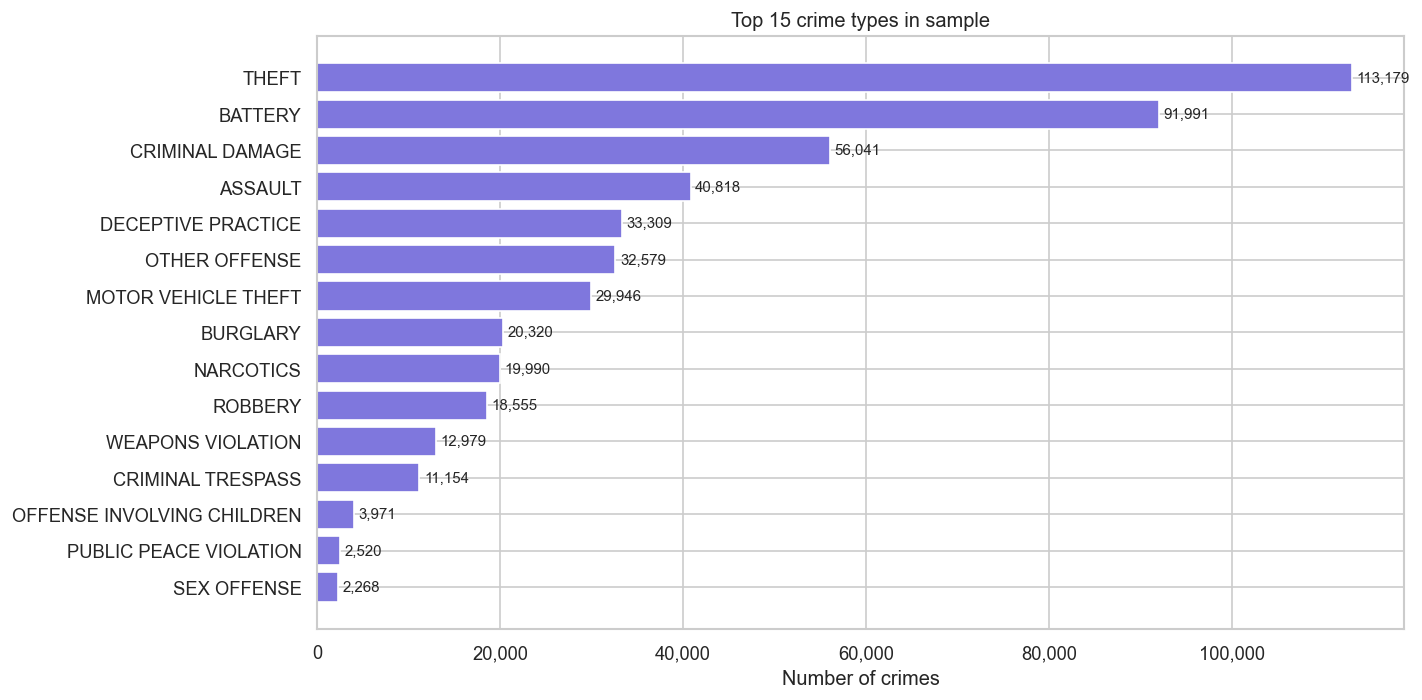

In [10]:
top_crimes = df["Primary Type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_crimes.index[::-1], top_crimes.values[::-1], color="#7F77DD")
ax.set_xlabel("Number of crimes")
ax.set_title("Top 15 crime types in sample")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, val in zip(bars, top_crimes.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("notebooks/plots/02_crime_types.png")
plt.show()

In [11]:
# Hourly crime pattern

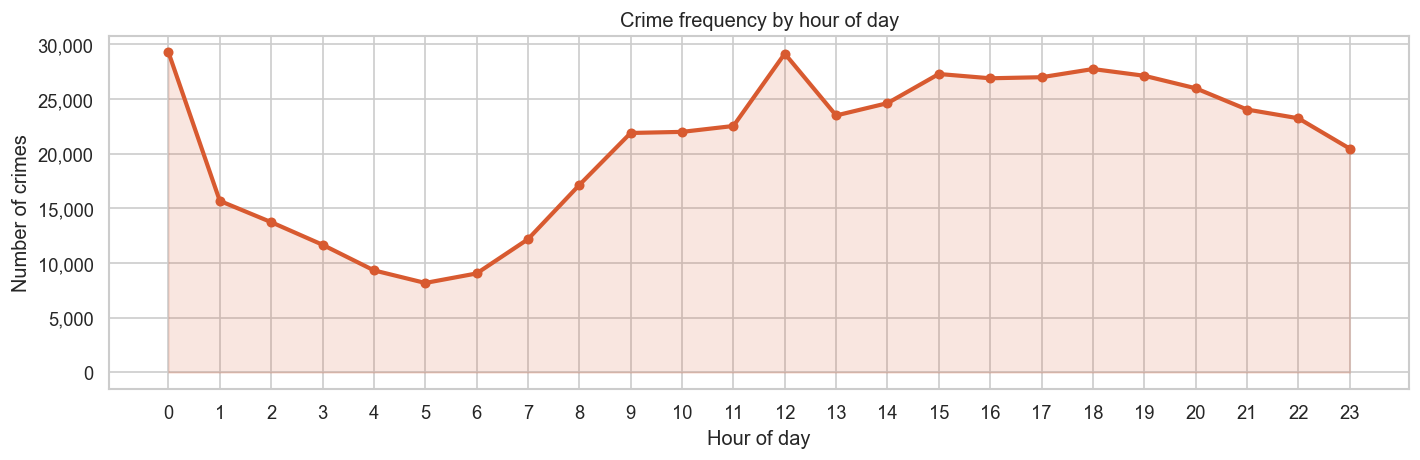

Peak crime hour : 0:00
Lowest crime hour: 5:00


In [12]:
hourly = df.groupby("Hour").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly["Hour"], hourly["count"], marker="o", color="#D85A30",
        linewidth=2.5, markersize=5)
ax.fill_between(hourly["Hour"], hourly["count"], alpha=0.15, color="#D85A30")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of crimes")
ax.set_title("Crime frequency by hour of day")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("notebooks/plots/03_hourly_pattern.png")
plt.show()

peak_hour = hourly.loc[hourly["count"].idxmax(), "Hour"]
low_hour  = hourly.loc[hourly["count"].idxmin(), "Hour"]
print(f"Peak crime hour : {peak_hour}:00")
print(f"Lowest crime hour: {low_hour}:00")

In [13]:
# Day of week pattern

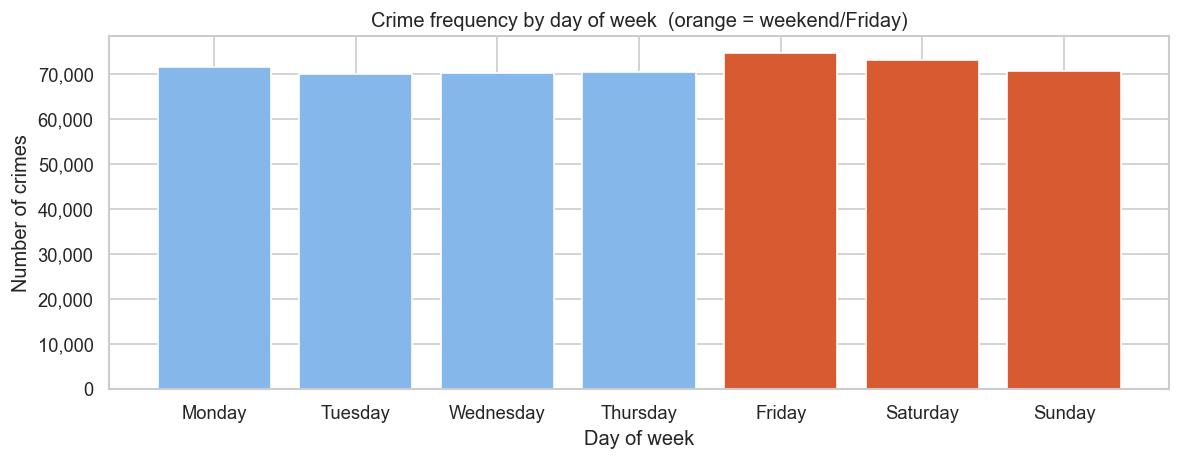

In [14]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily = df["Day_of_Week"].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#D85A30" if d in ["Friday","Saturday","Sunday"] else "#85B7EB" for d in day_order]
ax.bar(daily.index, daily.values, color=colors)
ax.set_xlabel("Day of week")
ax.set_ylabel("Number of crimes")
ax.set_title("Crime frequency by day of week  (orange = weekend/Friday)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("notebooks/plots/04_daily_pattern.png")
plt.show()

In [15]:
# Monthly & seasonal pattern

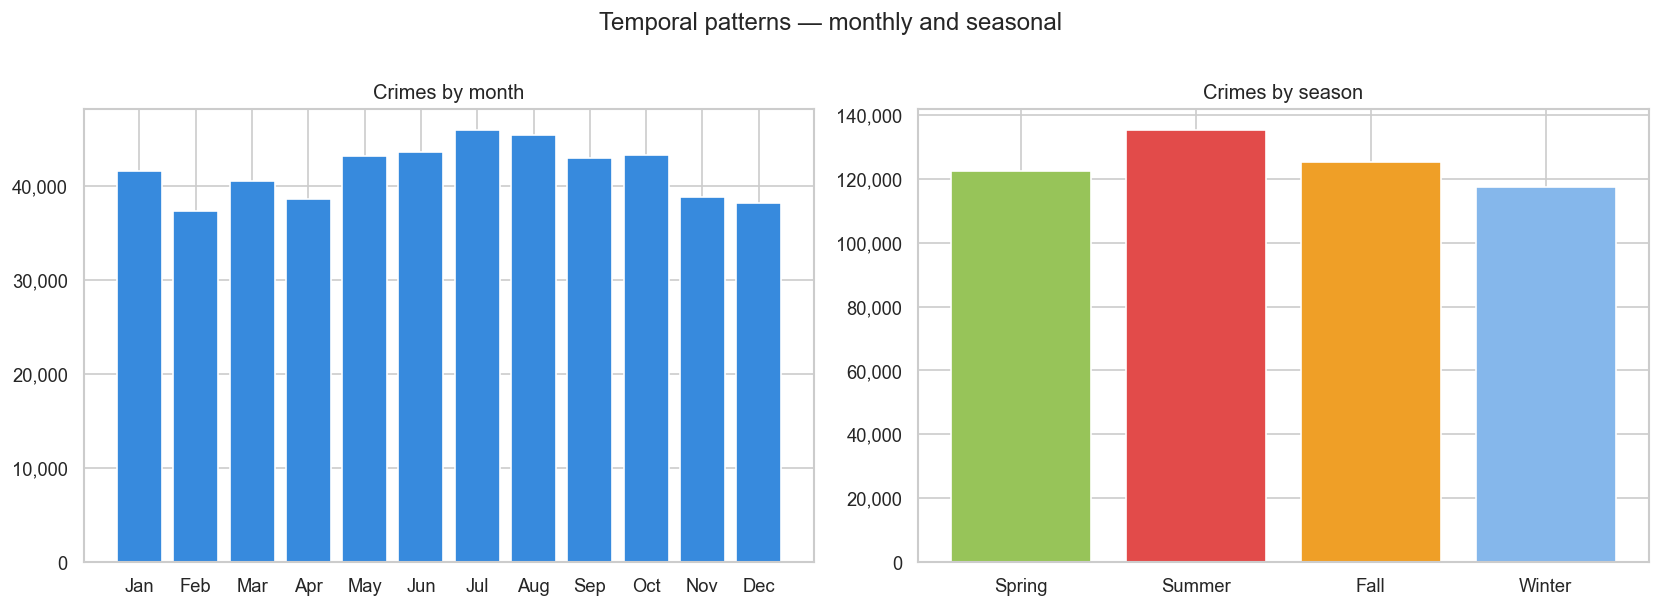

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby("Month").size()
axes[0].bar(monthly.index, monthly.values, color="#378ADD")
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[0].set_title("Crimes by month")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

seasonal = df["Season"].value_counts().reindex(["Spring","Summer","Fall","Winter"])
axes[1].bar(seasonal.index, seasonal.values,
            color=["#97C459","#E24B4A","#EF9F27","#85B7EB"])
axes[1].set_title("Crimes by season")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Temporal patterns — monthly and seasonal", y=1.01)
plt.tight_layout()
plt.savefig("notebooks/plots/05_monthly_seasonal.png")
plt.show()

In [17]:
# Arrest rate by crime type

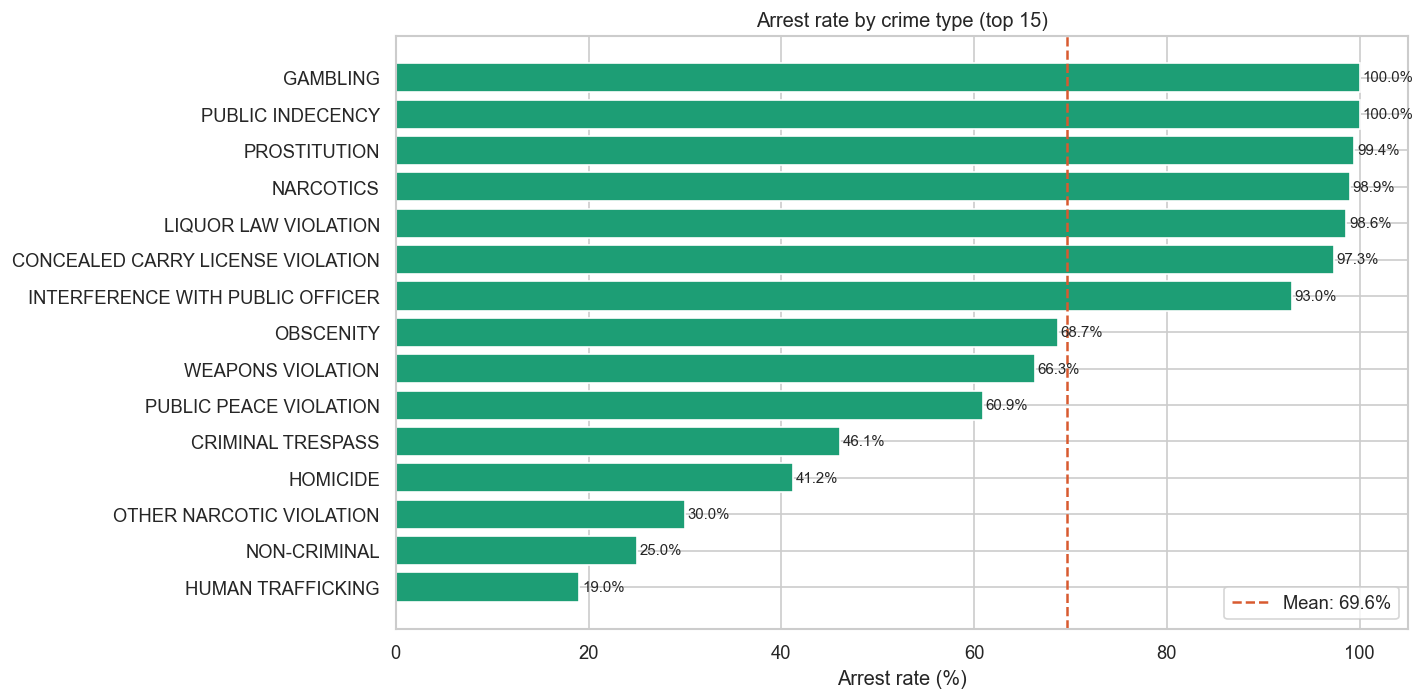

In [18]:
arrest_rate = (df.groupby("Primary Type")["Arrest"]
               .mean()
               .sort_values(ascending=False)
               .head(15) * 100)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(arrest_rate.index[::-1], arrest_rate.values[::-1], color="#1D9E75")
ax.set_xlabel("Arrest rate (%)")
ax.set_title("Arrest rate by crime type (top 15)")
ax.axvline(arrest_rate.mean(), color="#D85A30", linestyle="--",
           linewidth=1.5, label=f"Mean: {arrest_rate.mean():.1f}%")
ax.legend()

for bar, val in zip(bars, arrest_rate.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("notebooks/plots/06_arrest_rate.png")
plt.show()

In [19]:
#  District crime distribution

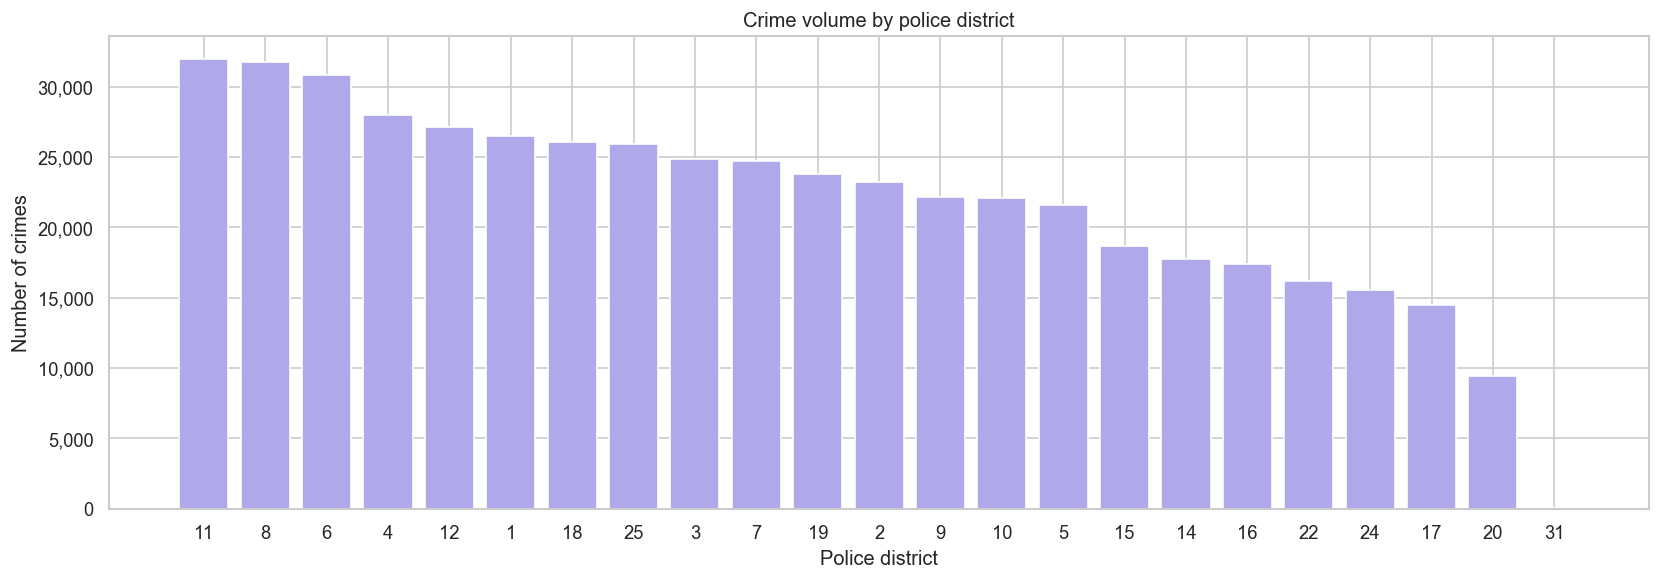

In [20]:
district_crimes = df.groupby("District").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(district_crimes.index.astype(str), district_crimes.values, color="#AFA9EC")
ax.set_xlabel("Police district")
ax.set_ylabel("Number of crimes")
ax.set_title("Crime volume by police district")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("notebooks/plots/07_district_crimes.png")
plt.show()

In [21]:
# Crime heatmap: hour vs day

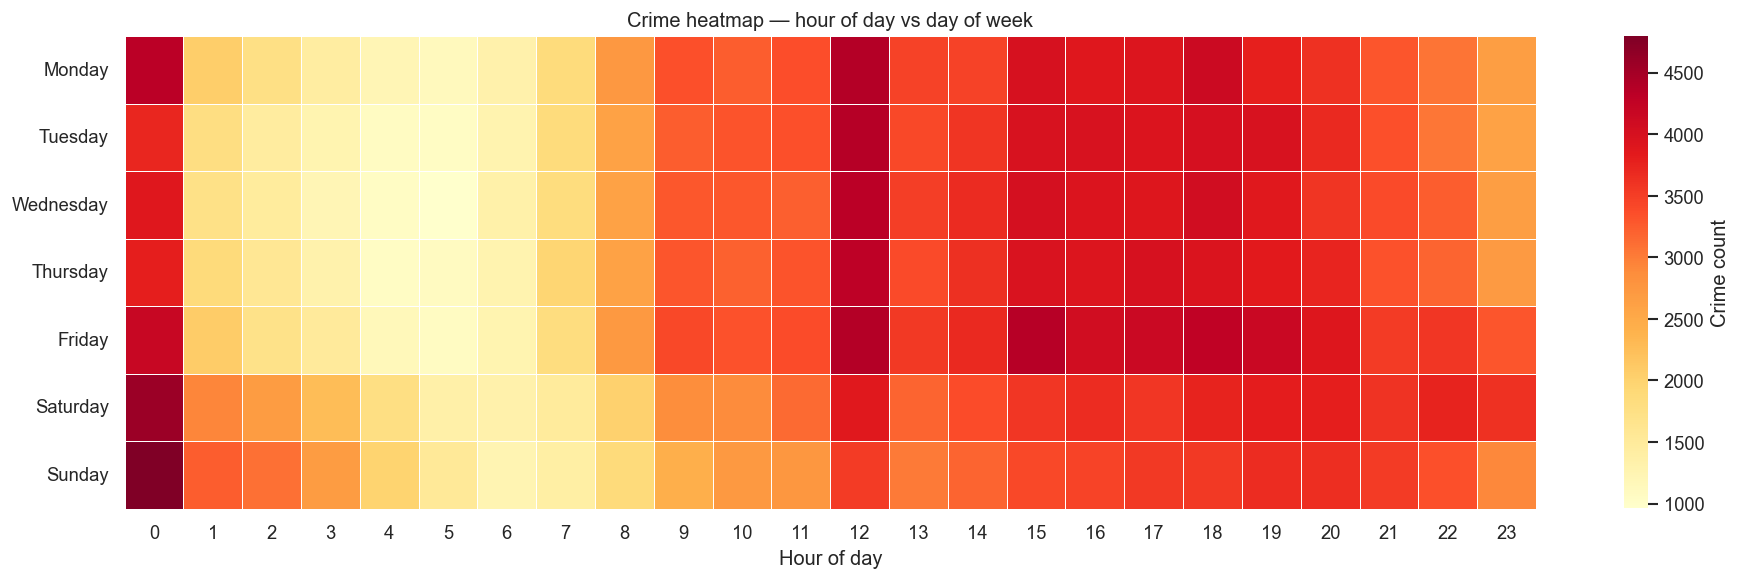

In [22]:
pivot = df.pivot_table(
    index="Day_of_Week", columns="Hour",
    values="ID", aggfunc="count"
).reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, fmt=",", linewidths=0.3,
            cbar_kws={"label": "Crime count"})
ax.set_title("Crime heatmap — hour of day vs day of week")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("notebooks/plots/08_heatmap_hour_day.png")
plt.show()

In [23]:
# Geographic scatter

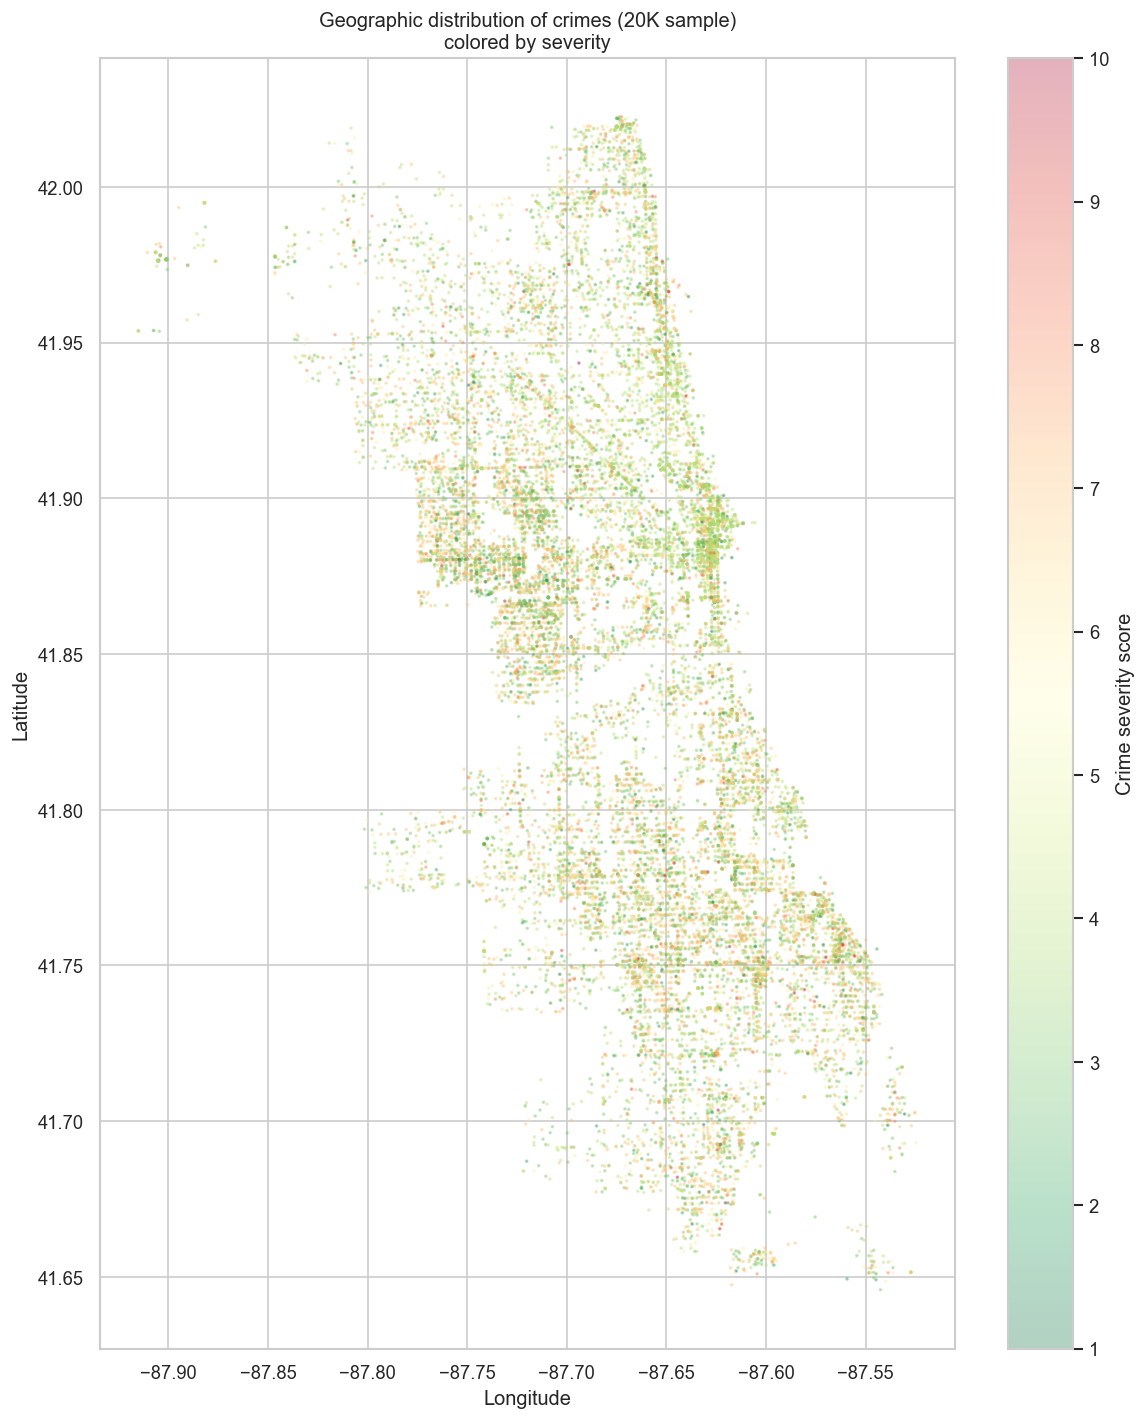

In [24]:
geo_sample = df.sample(20_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 12))
scatter = ax.scatter(
    geo_sample["Longitude"], geo_sample["Latitude"],
    c=geo_sample["Crime_Severity_Score"],
    cmap="RdYlGn_r", alpha=0.3, s=1.5
)
plt.colorbar(scatter, ax=ax, label="Crime severity score")
ax.set_title("Geographic distribution of crimes (20K sample)\ncolored by severity")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("notebooks/plots/09_geographic_scatter.png")
plt.show()

In [25]:
# Domestic vs non-domestic breakdown

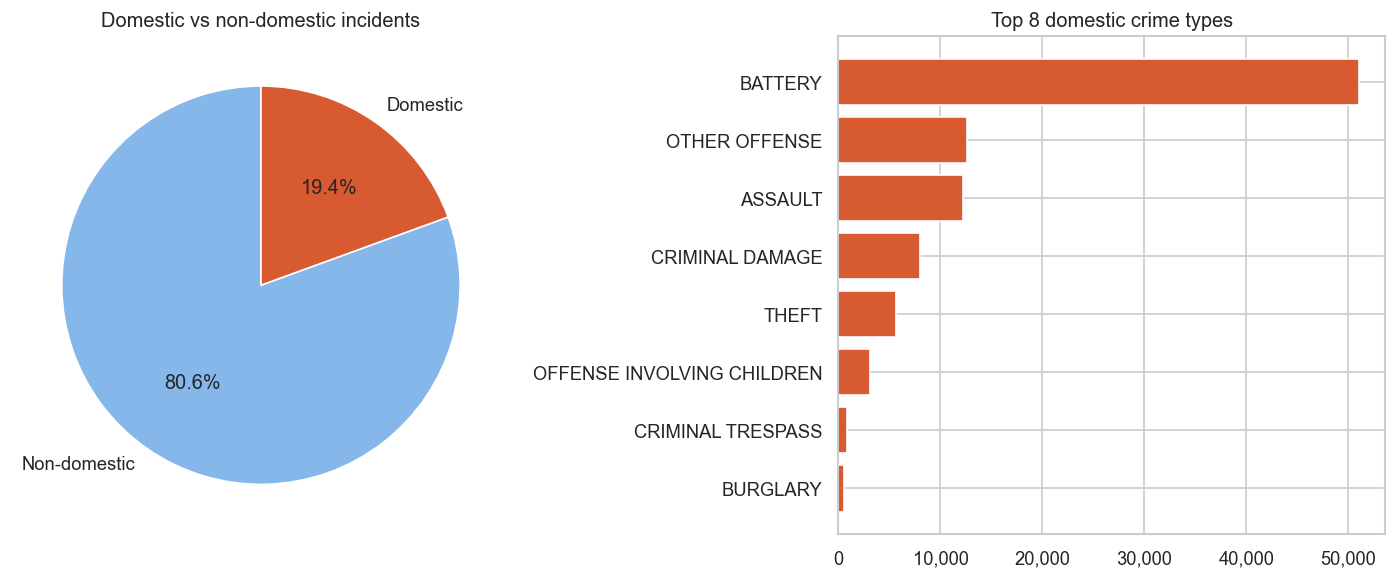

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

domestic_counts = df["Domestic"].value_counts()
axes[0].pie(domestic_counts.values,
            labels=["Non-domestic","Domestic"],
            autopct="%1.1f%%",
            colors=["#85B7EB","#D85A30"],
            startangle=90)
axes[0].set_title("Domestic vs non-domestic incidents")

dom_crimes = (df[df["Domestic"]==1]["Primary Type"]
              .value_counts().head(8))
axes[1].barh(dom_crimes.index[::-1], dom_crimes.values[::-1], color="#D85A30")
axes[1].set_title("Top 8 domestic crime types")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("notebooks/plots/10_domestic.png")
plt.show()

In [27]:
# Save cleaned data for ML

In [28]:
CLEAN_PATH = "../data/crimes_clean.parquet"
df.to_parquet(CLEAN_PATH, index=False)
size_mb = os.path.getsize(CLEAN_PATH) / (1024 * 1024)

print("=" * 55)
print("EDA COMPLETE — Cleaned dataset saved")
print("=" * 55)
print(f"  Output file  : {CLEAN_PATH}")
print(f"  File size    : {size_mb:.1f} MB")
print(f"  Shape        : {df.shape}")
print(f"  Plots saved  : notebooks/plots/  ({len(os.listdir('notebooks/plots'))} files)")
print("\n  Final column list:")
for col in sorted(df.columns):
    print(f"    {col}")
print("=" * 55)
print("Ready for Step 4 — Clustering Analysis.")

EDA COMPLETE — Cleaned dataset saved
  Output file  : ../data/crimes_clean.parquet
  File size    : 26.2 MB
  Shape        : (500000, 26)
  Plots saved  : notebooks/plots/  (10 files)

  Final column list:
    Arrest
    Beat
    Block
    Case Number
    Community Area
    Crime_Severity_Score
    Date
    Day_of_Week
    Description
    District
    Domestic
    FBI Code
    Hour
    ID
    IUCR
    Is_Weekend
    Latitude
    Location Description
    Longitude
    Month
    Primary Type
    Season
    Ward
    X Coordinate
    Y Coordinate
    Year
Ready for Step 4 — Clustering Analysis.
